<center>

**<font color = "red">Project: Classification of Medical Images</font>**

---
**<font color = "green">Pneumonia Detection in Chest X-Rays using Transfer Learning</font>**

*15 April 2026*

---

*L.Chen*

*e-mail: longjie.chen@ifj.edu.pl*

---

</center>


## Project Overview
**Objective:** Build a deep learning model to classify chest X-rays as **Normal** or **Pneumonia**.

**Model:** VGG16 (Transfer Learning) with custom classifier head  

**Training:** 25 epochs, Adam optimizer, data augmentation  

**Evaluation:** Accuracy, precision, recall, confusion matrix, F1-score

**Key Features:**
1. **Image size:** 224×224 (VGG16 native input)
2. **Base model:** VGG16 pre-trained on ImageNet (frozen as feature extractor)


### **Step 1: Setup and Data Acquisition**
First, we need to set up the Kaggle API to download the dataset.

**Action Required:**
1.  Create your own Kaggle API via and download your `kaggle.json` file.
2.  Run the code cell below. It will prompt you to upload the `kaggle.json`.


In [1]:
# Install Kaggle library
!pip install -q kaggle

from google.colab import files

print("Please upload your kaggle.json file")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\nKaggle API configured successfully!")

# Download and unzip the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q --unzip

print("Dataset downloaded and unzipped.")
!ls chest_xray  # Verify the directory structure


Please upload your kaggle.json file


Saving kaggle.json to kaggle.json

Kaggle API configured successfully!
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Dataset downloaded and unzipped.
chest_xray  __MACOSX  test  train  val


### **Step 2: Configuration and Data Preparation**
One needs to import the necessary Python libraries and define the key parameters(such as image size and batch size) before running.

**Key paramters:**

| Parameter | Value | Description |
|-----------|-------|-------------|
| **Image size** | 224×224 pixels | VGG16 native input size |
| **Batch size** | 32 | Images per training step |
| **Epochs** | 25 | Training cycles |
| **Learning rate** | 0.001 | Adam optimizer learning rate |
| **Data split** | Train/Val/Test | Pre-defined dataset split |

In [2]:
# ===================================================================
# Import Libraries
# ===================================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

BASE_DATA_PATH = '/content/chest_xray/'
TRAIN_DIR = BASE_DATA_PATH + 'train'
VALIDATION_DIR = BASE_DATA_PATH + 'val'
TEST_DIR = BASE_DATA_PATH + 'test'

# Image size for VGG16
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001


### **Step 3: Prepare Data with Augmentation**

Due to limited dataset, we need to create "new" training examples by applying random transformations.

**Training augmentations:**
- Rotation (±20°), shifting (±20%), zoom (±20%)
- Horizontal flipping (lungs are symmetric)
- Pixel normalization (0-255 → 0-1)

**Validation/Test:** Only normalization (no augmentation) for fair evaluation.



In [3]:
# Data Preparation and Preprocessing
# Training augmentations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test: only normalization
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
validation_generator = validation_test_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
test_generator = validation_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode='binary'
)

print("Found class indices:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


### **Step 4: Build Transfer Learning Model**

We use **VGG16** pre-trained on ImageNet as a feature extractor. The base model is frozen, and we add a custom classifier head.

### Model Architecture:

1. **VGG16 Base (Frozen):**
   - Frozen to prevent overfitting
   - Extracts hierarchical features (edges → textures → patterns)

2. **Global Average Pooling:**
   - More efficient than Flatten()
   - Reduces spatial dimensions to 1D feature vector

3. **Custom Classifier Head:**
   - Dense(256) with ReLU activation
   - Dropout(0.5) for regularization

In [4]:
# Load VGG16 pre-trained on ImageNet
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)
)
# Freeze the base model
base_model.trainable = False
print(f"Base model: VGG16 (ImageNet weights)")
print(f"Base model frozen: {not base_model.trainable}")
# Build the complete model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
# Display model architecture
print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model: VGG16 (ImageNet weights)
Base model frozen: True

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### **Step 5: Compile and Train the Model**
### Compilation Settings:
| Setting | Value | Reason |
|---------|-------|--------|
| **Loss function** | Binary cross-entropy | Standard for binary classification |
| **Optimizer** | Adam (lr=0.001) | Adaptive learning rate, good default |
| **Metrics** | Accuracy, Precision, Recall | Critical for medical diagnosis |

### Training Details:
- **Epochs:** 25
- **Batch size:** 32
- **Steps per epoch:** Training samples ÷ Batch size
- **Validation:** After each epoch


In [5]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    verbose=1
)


Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 153s 798ms/step - accuracy: 0.8041 - loss: 0.4169 - precision: 0.8218 - recall: 0.9401 - val_accuracy: 0.7500 - val_loss: 0.5551 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 726ms/step - accuracy: 0.8865 - loss: 0.2683 - precision: 0.9165 - recall: 0.9321 - val_accuracy: 0.7500 - val_loss: 0.4877 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 725ms/step - accuracy: 0.8974 - loss: 0.2411 - precision: 0.9269 - recall: 0.9357 - val_accuracy: 0.7500 - val_loss: 0.5472 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 706ms/step - accuracy: 0.9166 - loss: 0.2109 - precision: 0.9426 - recall: 0.9453 - val_accuracy: 0.7500 - val_loss: 0.3755 - val_precision: 0.7000 - val_recall: 0.8750
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 725ms/step - accuracy: 0.9179 - loss: 0.2013 - precision: 0.9445 - recall: 0.9450 - val_accuracy: 0

### **Step 6: Evaluate on Test Data**
Now we test our trained model on completely unseen images.

### Key Metrics:
1. **Accuracy:** Overall percentage of correct predictions
2. **Precision:** Of predicted pneumonia cases, how many actually have pneumonia?
   $
   \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
   $
3. **Recall:** Of actual pneumonia cases, how many did we detect?
   $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$
4. **F1-Score:** Harmonic mean of precision and recall
  $F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

  ### Confusion Matrix:
A confusion matrix provides a detailed breakdown of model predictions:
| | Predicted Normal | Predicted Pneumonia |
|----------------|-------------------|---------------------|
| **Actual Normal** | True Negative (TN) | False Positive (FP) |
| **Actual Pneumonia** | False Negative (FN) | True Positive (TP) |



Evaluating the Model on the Test Set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.8910 - loss: 0.3220 - precision: 0.8710 - recall: 0.9692

TEST SET PERFORMANCE
Test Accuracy:    89.10%
Test Precision:   87.10%
Test Recall:      96.92%
Test Loss:        0.3220
Test F1-Score:    91.75%
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step


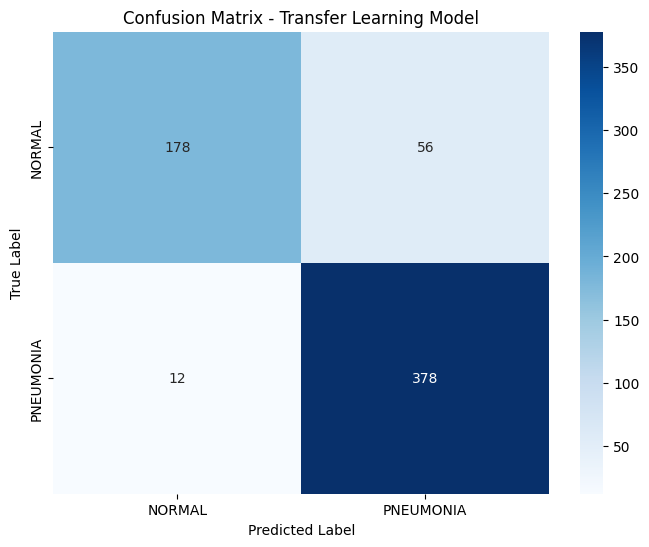


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL     0.9368    0.7607    0.8396       234
   PNEUMONIA     0.8710    0.9692    0.9175       390

    accuracy                         0.8910       624
   macro avg     0.9039    0.8650    0.8785       624
weighted avg     0.8957    0.8910    0.8883       624



In [6]:

print("Evaluating the Model on the Test Set...")

# Evaluate on test set
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print(f"\n" + "="*60)
print("TEST SET PERFORMANCE")
print("="*60)
print(f"Test Accuracy:    {test_accuracy*100:.2f}%")
print(f"Test Precision:   {test_precision*100:.2f}%")
print(f"Test Recall:      {test_recall*100:.2f}%")
print(f"Test Loss:        {test_loss:.4f}")

# Calculate F1-score
if test_precision + test_recall > 0:
    test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)
    print(f"Test F1-Score:    {test_f1*100:.2f}%")
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Transfer Learning Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(true_classes, predicted_classes,
                          target_names=class_labels, digits=4))


### **Step 7: Analyze Training History**
We plot the training and validation metrics to diagnose model behavior.

**What to look for:**
- **Good fit:** Training and validation curves converge
- **Overfitting:** Training accuracy keeps rising while validation plateaus
- **Underfitting:** Both curves plateau at low accuracy


Plotting training history...


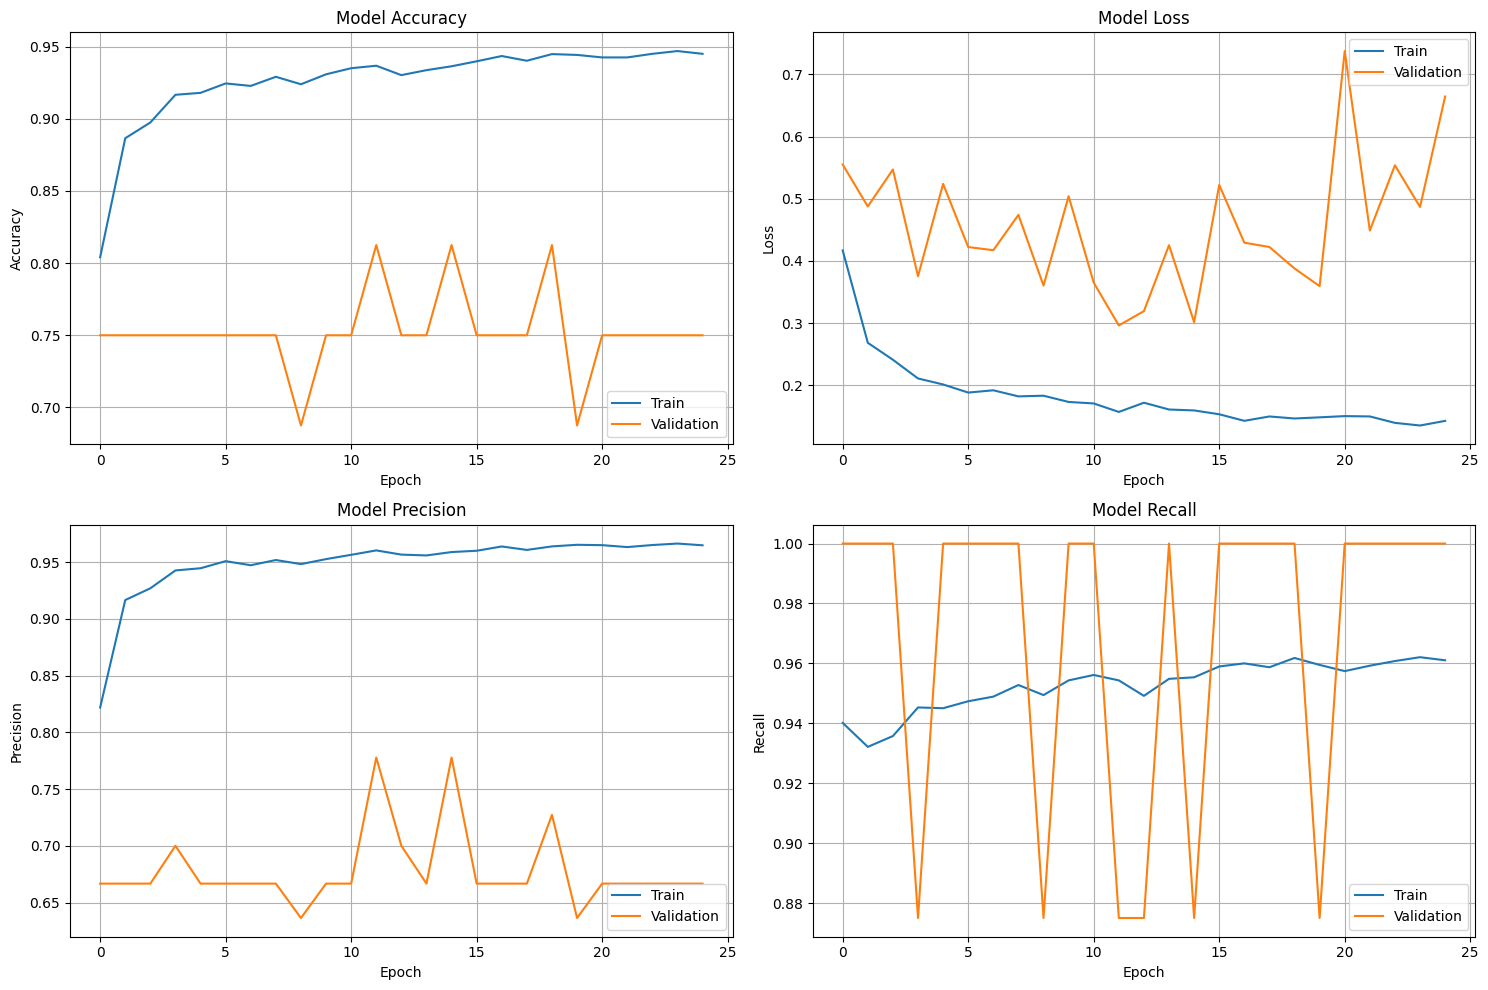

In [7]:
# Plot Training History
def plot_history(history):
    """Plot training and validation accuracy/loss curves."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'])
    axes[0, 0].plot(history.history['val_accuracy'])
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend(['Train', 'Validation'], loc='lower right')
    axes[0, 0].grid(True)

    # Loss
    axes[0, 1].plot(history.history['loss'])
    axes[0, 1].plot(history.history['val_loss'])
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend(['Train', 'Validation'], loc='upper right')
    axes[0, 1].grid(True)

    # Precision
    axes[1, 0].plot(history.history['precision'])
    axes[1, 0].plot(history.history['val_precision'])
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend(['Train', 'Validation'], loc='lower right')
    axes[1, 0].grid(True)

    # Recall
    axes[1, 1].plot(history.history['recall'])
    axes[1, 1].plot(history.history['val_recall'])
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend(['Train', 'Validation'], loc='lower right')
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
print("Plotting training history...")
plot_history(history)

### **Step 8: Visualize Sample Predictions**
We present comparison of predictions and actual results.

**Display:** 16 test images with:
- True label (Normal/Pneumonia)
- Predicted label  
- Green title = correct, Red title = incorrect

Visualizing sample predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step


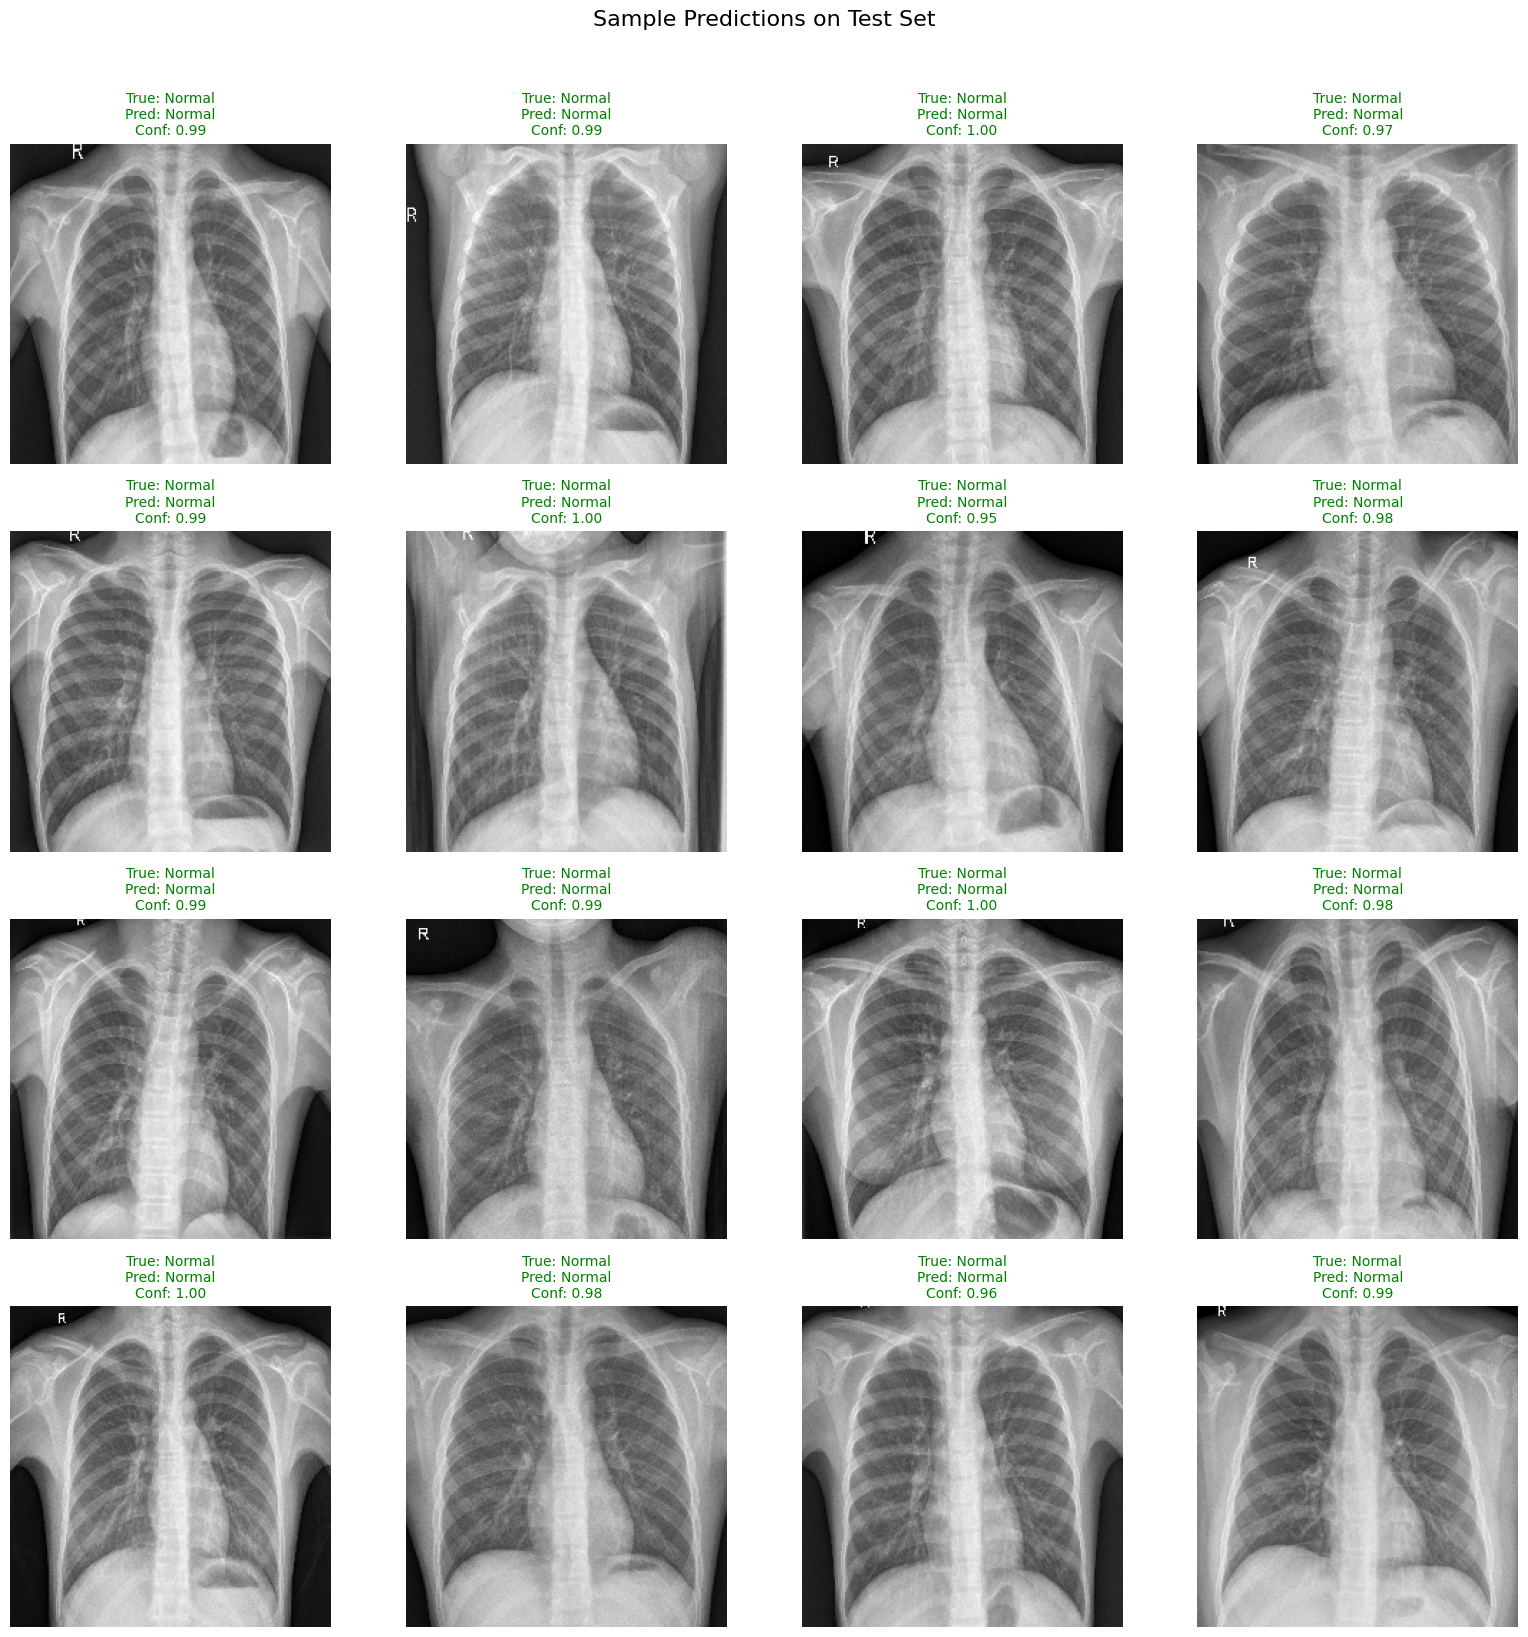

In [8]:

def show_sample_predictions(generator, model, num_samples=16):
    """Display sample test images with true and predicted labels."""
    x_batch, y_batch = next(generator)
    preds = model.predict(x_batch)
    pred_labels = (preds > 0.5).astype(int).flatten()

    # Calculate grid dimensions
    cols = 4
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.ravel()

    for i in range(num_samples):
        axes[i].imshow(x_batch[i])
        true_label = 'Pneumonia' if y_batch[i] == 1 else 'Normal'
        pred_label = 'Pneumonia' if pred_labels[i] == 1 else 'Normal'

        # Color code: green for correct, red for incorrect
        color = 'green' if true_label == pred_label else 'red'
        confidence = preds[i][0] if preds[i][0] > 0.5 else 1 - preds[i][0]

        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}',
                         color=color, fontsize=10)
        axes[i].axis('off')

    # Hide unused subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Sample Predictions on Test Set', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

print("Visualizing sample predictions...")
test_generator.reset()  # Reset to get a fresh batch
show_sample_predictions(test_generator, model, num_samples=16)
